We start by uploading the dataset we wish to work with. This is a dataset on factors affecting educational outcomes in secondary education in Portugal.

In [1]:
import pandas as pd

df = pd.read_csv("education_data.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [2]:
import statsmodels.api as sm
print(df.columns) # Doing this to check that the data looks correct
print(df.info())

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null 

The first thing we wish to test is if we can fit a linear regression to this data

In [3]:
y = df["G3"] # G3 is the final exam scores (/20) we call it y because it is our target variable for this

covariates = [ # We list all of the potential covariates
    "school", "sex", "age", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
    "traveltime", "studytime", "failures", "schoolsup",
    "famsup", "paid", "activities", "nursery", "higher",
    "internet", "romantic", "famrel", "freetime", "goout",
    "Dalc", "Walc", "health", "absences", "G1", "G2"
]

In [4]:
X = pd.get_dummies( # Here we split the categorical covariates up into binary covariates (i.e sex_M and sex_F as opposed to sex)
    df[covariates],
    drop_first=True,
    dtype=int
)

X.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,0,4,3,2,2,...,1,0,1,0,0,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,0,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,0,0,1,1,0,0


In [5]:
print(X.columns.tolist()) # Again we just check that the new columns in the updated dataset look correct 

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


We now wish to perform a stepwise selection to decide on which of the covariates to include in the model. We have chosen to do a stepwise selection as we had previously learnt about this in modules last year. We thought that using the full set of covariates probably wouldn't make sense as this model would be too complex. We produced a function to carry out the stepwise selection using prior knowledge and course materials as well as using chatGPT to help produce some of the more complex aspects of the code, before annotating it ourselves.

In [6]:
import statsmodels.api as sm

def stepwise_selection(X, y, significance_level=0.05): # We define a function to carry out this stepwise selection
    
    selected = [] # We create sets to include the covariates that the model will select
    remaining = list(X.columns) # And a set to include the covariates left out
    # Initially there are none selected, hence why the set is empty for now
    while True: # We do this to track whether anything is changing through each cycle of forwards and backwards
        
        changed = False # If we get to the point where nothing changes we terminate the process
        
        # Forward selection
        best_variable = None # Initially we don't have a 'best' variable to choose
        best_p = None
        
        for variable in remaining: # Take a variable that isn't currently selected
            
            variables = selected + [variable] # We create a new list temporarily that includes this variable
            
            model = sm.OLS( # We fit a linear regression on these covarites
                y,
                sm.add_constant(X[variables])
            ).fit()
            
            p_value = model.pvalues[variable] # Get a p-value for the model with this additional covariate
            
            if best_p is None or p_value < best_p: 
                best_p = p_value
                best_variable = variable # If this is the best potential covariate so far we update current selected
        
        if best_p is not None and best_p < significance_level: 
            # If the p-value associated with our new potential covariate is < the desired significance level
            selected.append(best_variable) # We add this covariate to the selection
            remaining.remove(best_variable) # And remove it from the list of not selected variable
            print("Adding:", best_variable)
            changed = True # If we added a new variable, our loop continues
        
        # Backward selection
        if selected:
            
            model = sm.OLS( # Fit a model with all of the currently selected covariates
                y,
                sm.add_constant(X[selected])
            ).fit()
            
            p_values = model.pvalues.drop("const")
            worst_p = p_values.max() # Takes the covariate with the lowest p-value in the current linear regression
            
            if worst_p > significance_level: # If this less significant than our desired significance level
                worst_variable = p_values.idxmax() # Finds the covariate with the highest p-value
                selected.remove(worst_variable) # Removes from the selected list
                remaining.append(worst_variable) # Adds back to the list of covariates which arent currently selected
                print("Removing:", worst_variable)
                changed = True # If we deleted a variable, continue the loop
        
        if not changed: # If the lists stop changing
            break # Terminate the loop
    
    return selected # Return the list of covariates deemed significant in this selection

In [7]:
selected_covariates = stepwise_selection(X, y) # We now run this function on our dataset to covariates to use in the linear regression

print(selected_covariates)

Adding: G2
Adding: G1
Adding: reason_other
Adding: failures
['G2', 'G1', 'reason_other', 'failures']


In [8]:
X_selected = X[selected_covariates] # We now fit a linear model to these selected covariates

final_model = sm.OLS(
    y,
    sm.add_constant(X_selected)
).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     919.9
Date:                Tue, 06 Oct 2026   Prob (F-statistic):          1.43e-264
Time:                        13:12:19   Log-Likelihood:                -1063.6
No. Observations:                 649   AIC:                             2137.
Df Residuals:                     644   BIC:                             2160.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2095      0.243      0.861   

We have now fitted a linear model to this dataset. Unfortunately, these results are really uninteresting, essentially stating that previous exam results and number of failures of classes is the biggest indicator of how a student will perform in their final exam. We probably didn't need to do much data analysis to find this and it is not really the type of thing we wanted to analyse, so we will remove G1, G2 and failures from the dataset and fit the model again to see if we can find any more interesting results.

In [9]:
df_new = df.drop(columns=["G1", "G2", "failures"])

y_new = df_new["G3"] # G3 is the final exam scores (/20) we call it y because it is our target variable for this

covariates = [ # We list all of the potential covariates
    "school", "sex", "age", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
    "traveltime", "studytime", "schoolsup",
    "famsup", "paid", "activities", "nursery", "higher",
    "internet", "romantic", "famrel", "freetime", "goout",
    "Dalc", "Walc", "health", "absences",
]

X_new = pd.get_dummies( # Here we split the categorical covariates up into binary covariates (i.e sex_M and sex_F as opposed to sex)
    df_new[covariates],
    drop_first=True,
    dtype=int
)

X_new.head()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,4,3,4,1,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,5,3,3,1,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,4,3,2,2,3,...,1,0,1,0,0,0,1,1,1,0
3,15,4,2,1,3,3,2,2,1,1,...,1,0,0,1,0,1,1,1,1,1
4,16,3,3,1,2,4,3,2,1,2,...,0,0,0,1,0,0,1,1,0,0


In [10]:
selected_covariates_new = stepwise_selection(X_new, y_new) # We now run this function on our dataset to covariates to use in the linear regression

print(selected_covariates_new)

Adding: higher_yes
Adding: school_MS
Adding: studytime
Adding: Dalc
Adding: schoolsup_yes
Adding: Fedu
Adding: health
Adding: sex_M
Adding: absences
['higher_yes', 'school_MS', 'studytime', 'Dalc', 'schoolsup_yes', 'Fedu', 'health', 'sex_M', 'absences']


In [11]:
X_selected_new = X_new[selected_covariates_new] # We now fit a linear model to these selected covariates

final_model_2 = sm.OLS(
    y_new,
    sm.add_constant(X_selected_new)
).fit()

print(final_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     25.90
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           3.72e-38
Time:                        13:13:38   Log-Likelihood:                -1580.6
No. Observations:                 649   AIC:                             3181.
Df Residuals:                     639   BIC:                             3226.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            10.3792      0.610     17.003

We now wish to create some plots which can allow us to assess how good at predicting the outcomes our selected covariates are, and if the assumption of a linear regression seems appropriate for the data. Given the R-squared value being 0.267, our initial thoughts are that this model probably isn't very good.

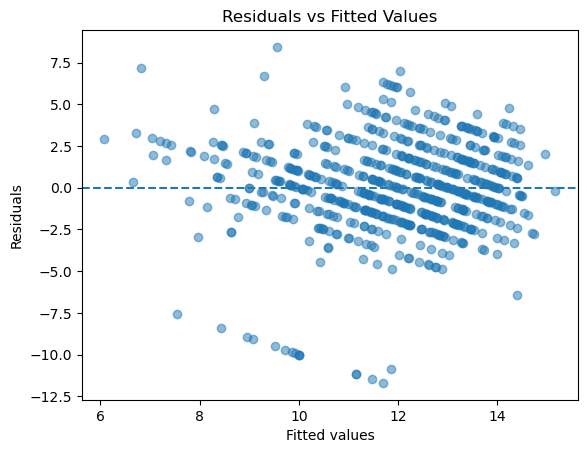

In [16]:
import matplotlib.pyplot as plt

# Extract fitted values and residuals
fitted_values = final_model_2.fittedvalues
residuals = final_model_2.resid

# Plot residuals against fitted values
plt.scatter(fitted_values, residuals, alpha=0.5)

# Add horizontal line at zero
plt.axhline(y=0, linestyle="--")

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

This skew to the right in this plot means the data probably violates the linearity assumption of the linear model.

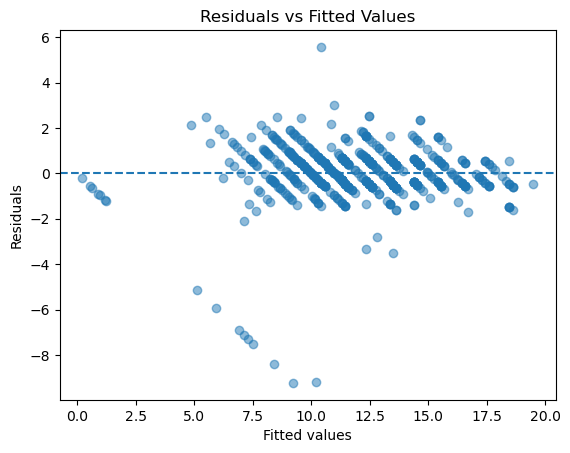

In [13]:
residuals = final_model.resid
fitted = final_model.fittedvalues

plt.scatter(fitted, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

This plot suggests that the data probably doesn't violate the equal variance of observations assumption.

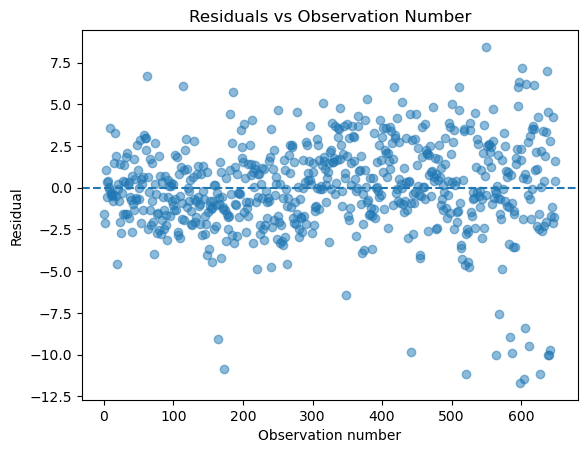

In [17]:
# Observation numbers: 1, 2, ..., n
observation_number = range(1, len(residuals) + 1)

plt.scatter(observation_number, residuals, alpha=0.5)

# Add horizontal line at zero
plt.axhline(y=0, linestyle="--")

plt.xlabel("Observation number")
plt.ylabel("Residual")
plt.title("Residuals vs Observation Number")

plt.show()

This plot suggests that the data probably doesn't violate the indepence of observations assumption.

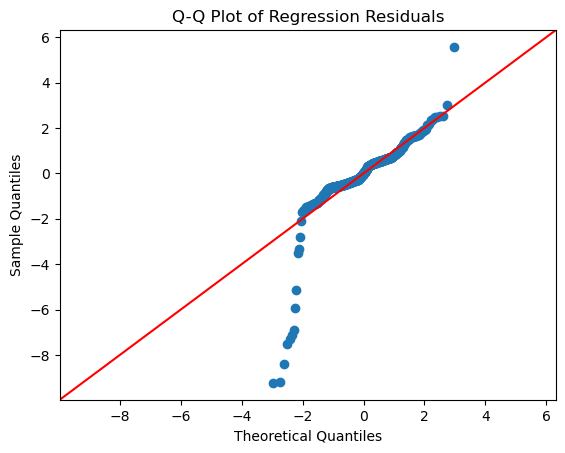

In [15]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(residuals, line="45")

plt.title("Q-Q Plot of Regression Residuals")

plt.show()

This plot suggests that there is a heavy tail, and the normality assumption of the linear model is violated.

Overall, these plots suggest that using a linear model is not an effective way of modelling the data due to violations of the assumptions in a linear model.